makemore:part 3

In [9]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words=open('names.txt','r').read().splitlines()

In [10]:
# build the vocabulary of characters and mappings to/from integers
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
vocab_size = len(itos)
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [12]:
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [82]:
# ML revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [83]:
(torch.randn(10000)*0.2).std()

tensor(0.1987)

In [84]:
(5/3)/(30**0.5)

0.3042903097250923

tensor(-0.0023) tensor(1.0032)
tensor(-0.0013) tensor(0.9935)


(array([0.00135904, 0.00067952, 0.00203856, 0.00067952, 0.01019281,
        0.00883377, 0.00747473, 0.01426993, 0.01630849, 0.0332965 ,
        0.03873267, 0.06047732, 0.08561958, 0.10396664, 0.12503177,
        0.15017403, 0.19366334, 0.2120104 , 0.2684106 , 0.29627094,
        0.32888792, 0.35335066, 0.37101819, 0.42130271, 0.37305675,
        0.40363518, 0.37917244, 0.3744158 , 0.31937464, 0.3282084 ,
        0.28268053, 0.24938402, 0.215408  , 0.16444396, 0.13522458,
        0.11619801, 0.09173527, 0.06659301, 0.06115685, 0.03941219,
        0.02446274, 0.02242418, 0.01155185, 0.01223137, 0.00747473,
        0.00679521, 0.0033976 , 0.        , 0.00203856, 0.00067952]),
 array([-3.65477061, -3.50760802, -3.36044542, -3.21328283, -3.06612023,
        -2.91895764, -2.77179504, -2.62463245, -2.47746985, -2.33030726,
        -2.18314466, -2.03598207, -1.88881948, -1.74165688, -1.59449429,
        -1.44733169, -1.3001691 , -1.1530065 , -1.00584391, -0.85868131,
        -0.71151872, -0.56

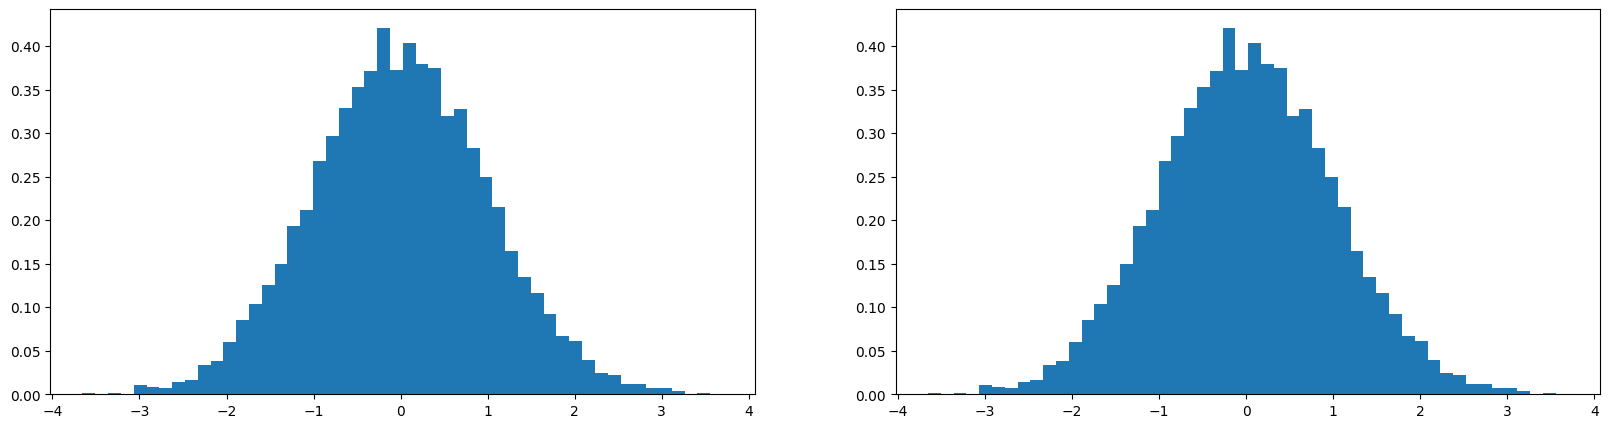

In [85]:
x=torch.randn(1000,10)
w=torch.randn(10,200) /10**0.5
y=x@w
print(x.mean(),x.std())
print(y.mean(),y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50,density=True)
plt.subplot(122)
plt.hist(x.view(-1).tolist(),50,density=True)


In [65]:
hpreact.shape

torch.Size([32, 200])

In [86]:
hpreact.mean(0,keepdim=True).shape

torch.Size([1, 200])

In [87]:
hpreact.std(0,keepdim=True).shape

torch.Size([1, 200])

In [100]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

  # Linear layer
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  hpreact=bngain*(hpreact-hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True)+bnbias
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
    
  

      0/ 200000: 2.2971
  10000/ 200000: 1.8519
  20000/ 200000: 2.2436
  30000/ 200000: 2.2882
  40000/ 200000: 2.0671
  50000/ 200000: 2.3681
  60000/ 200000: 2.1691
  70000/ 200000: 2.3869
  80000/ 200000: 2.1136
  90000/ 200000: 2.2860
 100000/ 200000: 1.8202
 110000/ 200000: 2.3726
 120000/ 200000: 2.1233
 130000/ 200000: 2.0573
 140000/ 200000: 2.2113
 150000/ 200000: 2.1209
 160000/ 200000: 2.0672
 170000/ 200000: 1.8362
 180000/ 200000: 2.3881
 190000/ 200000: 2.1354


In [72]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

In [73]:
h


tensor([[ 0.9572, -0.9455,  0.5480,  ..., -0.9466, -0.8579,  0.8107],
        [-0.6082, -0.3452, -0.0335,  ...,  0.1823, -0.4480, -0.0579],
        [ 0.5160, -0.0573,  0.8609,  ..., -0.9850, -0.9882,  0.4538],
        ...,
        [-0.8873, -0.3367,  0.6450,  ..., -0.4914,  0.8218,  0.7753],
        [ 0.8991,  0.5472, -0.9659,  ..., -0.6107,  0.3007,  0.9164],
        [-0.6790,  0.0482,  0.6413,  ..., -0.6349,  0.8973,  0.1510]],
       grad_fn=<TanhBackward0>)

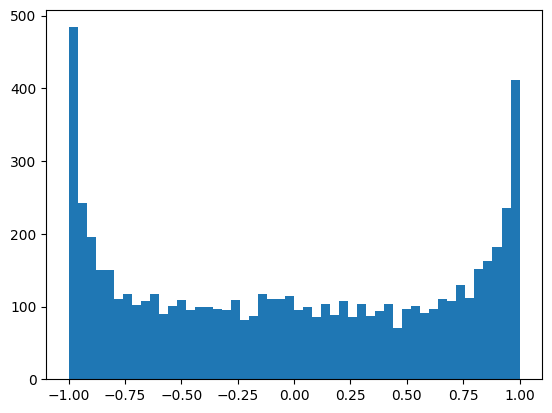

In [74]:
plt.hist(h.view(-1).tolist(),50);

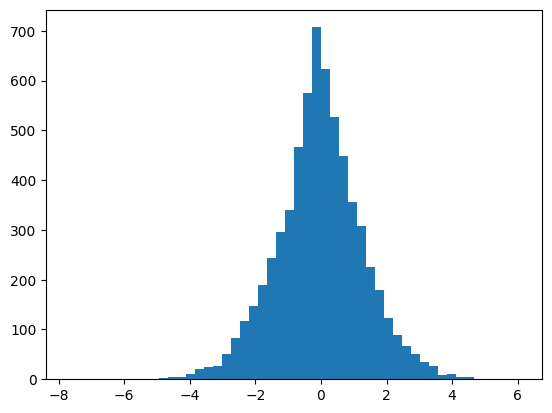

In [75]:
plt.hist(hpreact.view(-1).tolist(),50);

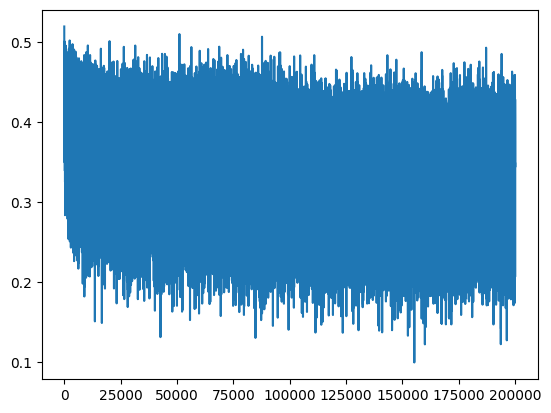

In [76]:
plt.plot(lossi)

In [93]:

# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)
    

In [97]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0648467540740967
val 2.127988815307617


## loss log
original:
train 2.1245384216308594 val 2.168196439743042

# fix softmax confidently wrong:
train 2.07 val 2.13

## fix tanh layer too saturated at init:
train 2.0355966091156006 val 2.1026785373687744

## use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693 val 2.106989622116089

## add batch norm layer
train 2.0668270587921143 val 2.104844808578491

In [98]:
# sample from the model 
g=torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out=[]
    context=[0]* block_size 
    while True:
        # forward pass the neural net 
        emb=C[torch.tensor([context])]
        h=torch.tanh(emb.view(1,-1) @ W1 +b1)
        logits=h @ W2 +b2 
        probs=F.softmax(logits,dim=1)
        # sample from the distribution 
        ix=torch.multinomial(probs,num_samples=1,generator=g).item()
        # shift the context window and track the samples 
        context=context[1:] +[ix]
        out.append(ix)
        if ix==0:
            break

    print(''.join(itos[i] for i in out))
        

catpa.
fatwyn.
vifksmruththtyksstansleja.
bubrddyssahthrrquightkthritziriivanglmilsh.
blavord.
quinthshlilla.
viviquiszefrudharuxikkimburhssabbertgy.
gabbigglutafrashpas.
burthksyahnaqiovohtan.
bjstorias.
genekz.
sadlucofgorgstynveghubnce.
quilmanryah.
bellexqhels.
bbdayadze.
tatswavivllidrnyctislaykerlth.
fzuswnndrett.
blskaythzambreck.
kypadylanorgubrkobberushfrrlyssalyszes.
buxell.
